In [21]:
import numpy as np

import torch.nn as nn
import torch
import torch.nn.functional as F

from tqdm.auto import tqdm

import models
import inference
import utils
import visu
import data
import aggregation

In [13]:
category = 15
size = 128
checkpoint = 'best_unet.pth'

train_dataset, test_dataset = data.single_cat_OxfordIIITPet(category)

  0%|          | 0/3680 [00:00<?, ?it/s]

  0%|          | 0/3669 [00:00<?, ?it/s]

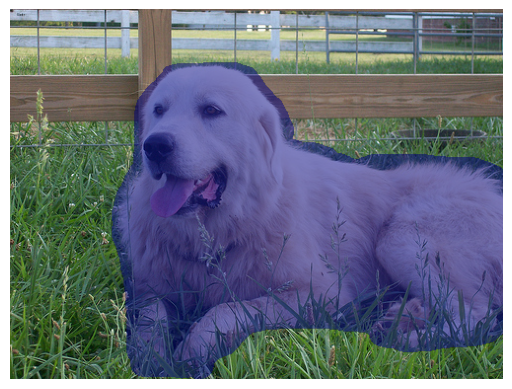

In [3]:
i = 0

image, (mask, cat) = train_dataset[i]
mask = utils.preprocess(mask)

visu.plot_mask(image, mask)

In [4]:
class CNNUnary(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=kernel_size, padding='same'),
            nn.ReLU(),
            nn.Conv2d(16, 64, kernel_size=kernel_size, padding='same'),
            nn.ReLU(),
            nn.Conv2d(64, 16, kernel_size=kernel_size, padding='same'),
            nn.ReLU(),
            nn.Conv2d(16, 2, kernel_size=kernel_size, padding='same'),
        )
    
    def forward(self, x):
        
        x = (x - x.mean(dim=(2, 3), keepdim=True)) / x.std(dim=(2, 3), keepdim=True)
        return self.model(x)
    
    def predict_probas(self, x):
        x = np.array(x)
        x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0)
        self.eval()
        with torch.no_grad():
            logits = self(x.float())
        probs = F.softmax(logits, dim=1)
        return probs[0].permute(1, 2, 0).detach().cpu().numpy()

    def predict(self, x):
        probas = self.predict_probas(x)
        return np.argmax(probas, axis=2)

class CNNSegment():
    
    def __init__(self, model, beta=1, sigma=100):
        
        self.model = model
        
        self.beta = beta
        self.sigma = sigma
    
    def predict(self, features):
        return self.model.predict(features)
    
    def __call__(self, features, max_iter, trw=False):
        probas = self.model.predict_probas(features)
        graph = utils.segmentation_graph_from_proba_map(features, probas, self.beta, self.sigma)
        if trw:
            graph.compute_rho_uniform_spanning_tree()
            marginals = inference.trw_bp(graph, max_iter)
        else:
            marginals = inference.loopy_bp(graph, max_iter)
        mask = utils.image_from_marginals(features, marginals)
        return mask

In [5]:
classifier = CNNUnary()
classifier.load_state_dict(torch.load(checkpoint, map_location='cpu'))

model = CNNSegment(classifier)

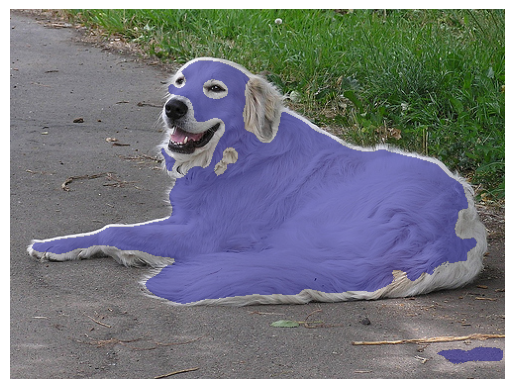

0.6788527144842691


In [25]:
i = 0
threshold = 0.01
max_iter = 100

image, (mask, cat) = test_dataset[i]
mask = utils.preprocess(mask)

predictions = model.predict(image)

visu.plot_mask(image, predictions)
print(utils.IoU(mask, predictions))

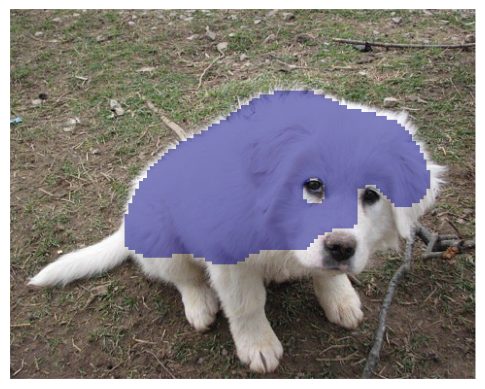

0.5204933775305516


In [ ]:
i = 7
threshold = 0.01
max_iter = 100

image, (mask, cat) = test_dataset[i]
mask = utils.preprocess(mask)
downscaled_image, downscaled_mask = utils.downscale(image, mask, size)

predictions = model(downscaled_image, max_iter, trw=False)
predictions = utils.upscale(predictions, image.size) > threshold

visu.plot_mask(image, predictions)
print(utils.IoU(mask, predictions))

In [ ]:
max_iter = 100

ious = inference.sequential_segmentation(test_dataset, model, max_iter, trw=False, downscale_size=size, threshold=threshold)
print("Mean IoU:", ious.mean())

  0%|          | 0/100 [00:00<?, ?it/s]

Mean IoU: 0.43839579065926765


In [22]:
threshold = 0.01
max_iter = 100

ious = []

for image, (mask, cat) in tqdm(test_dataset):
    mask = utils.preprocess(mask)
    predictions = model.predict(image)
    ious.append(utils.IoU(mask, predictions))

ious = np.array(ious)
print("Mean IoU:", ious.mean())

  0%|          | 0/100 [00:00<?, ?it/s]

Mean IoU: 0.5024263909458565
